FIRST 5 ROWS
                                    Complaint     Category
0               My credit card payment failed  Credit Card
1            Credit card transaction declined  Credit Card
2           Unable to activate my credit card  Credit Card
3                Credit card limit is too low  Credit Card
4  Annual credit card fee charged incorrectly  Credit Card

DATASET SHAPE
Rows    : 40
Columns : 2

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Complaint  40 non-null     object
 1   Category   40 non-null     object
dtypes: object(2)
memory usage: 772.0+ bytes

MISSING VALUES
Complaint    0
Category     0
dtype: int64

DUPLICATE ROWS
Duplicate Rows : 0

CLASS DISTRIBUTION
Category
Account             10
Loan                 5
Credit Card          5
Transaction          5
Internet Banking     5
KYC                  5
Customer

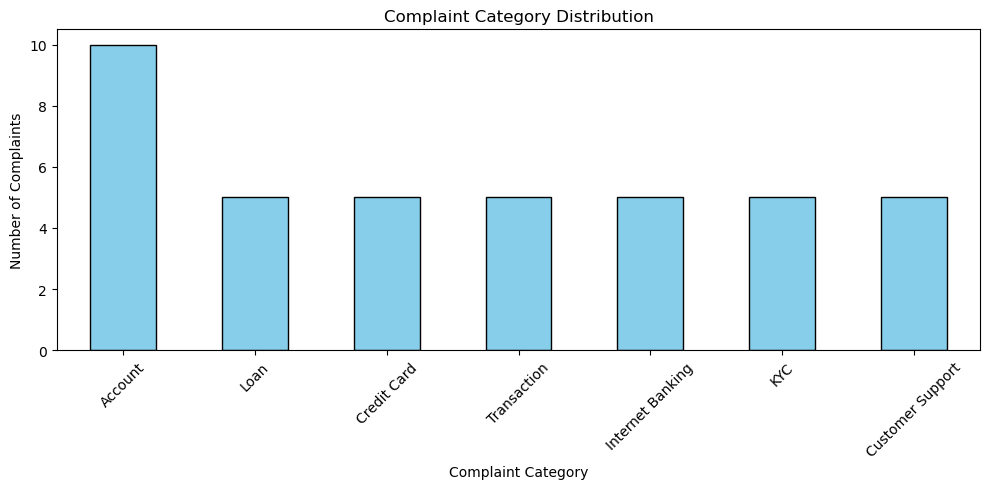


SUMMARY
                            Complaint Category
count                              40       40
unique                             40        7
top     My credit card payment failed  Account
freq                                1       10

STEP 3 COMPLETED SUCCESSFULLY


In [3]:
# ==========================================================
# AI Banking Assistant
# Module 9 - Complaint Classification
# Step 3 - Load Dataset
# ==========================================================

# ==========================================================
# Import Libraries
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nltk

from sklearn.model_selection import train_test_split

# ==========================================================
# Load Dataset
# ==========================================================

df = pd.read_csv(
    r"..\datasets\complaints.csv"
)
# ==========================================================
# Display First Rows
# ==========================================================

print("=" * 70)
print("FIRST 5 ROWS")
print("=" * 70)

print(df.head())

# ==========================================================
# Dataset Shape
# ==========================================================

print("\n" + "=" * 70)
print("DATASET SHAPE")
print("=" * 70)

print("Rows    :", df.shape[0])
print("Columns :", df.shape[1])

# ==========================================================
# Dataset Information
# ==========================================================

print("\n" + "=" * 70)
print("DATASET INFORMATION")
print("=" * 70)

df.info()

# ==========================================================
# Missing Values
# ==========================================================

print("\n" + "=" * 70)
print("MISSING VALUES")
print("=" * 70)

print(df.isnull().sum())

# ==========================================================
# Duplicate Rows
# ==========================================================

print("\n" + "=" * 70)
print("DUPLICATE ROWS")
print("=" * 70)

print("Duplicate Rows :", df.duplicated().sum())

# ==========================================================
# Remove Duplicate Rows (Optional)
# ==========================================================

df = df.drop_duplicates()

# ==========================================================
# Class Distribution
# ==========================================================

print("\n" + "=" * 70)
print("CLASS DISTRIBUTION")
print("=" * 70)

print(df["Category"].value_counts())

# ==========================================================
# Display Unique Categories
# ==========================================================

print("\n" + "=" * 70)
print("AVAILABLE CATEGORIES")
print("=" * 70)

print(df["Category"].unique())

# ==========================================================
# Plot Class Distribution
# ==========================================================

plt.figure(figsize=(10,5))

df["Category"].value_counts().plot(
    kind="bar",
    color="skyblue",
    edgecolor="black"
)

plt.title("Complaint Category Distribution")
plt.xlabel("Complaint Category")
plt.ylabel("Number of Complaints")
plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

# ==========================================================
# Summary Statistics
# ==========================================================

print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)

print(df.describe(include="all"))

# ==========================================================
# Step Completed
# ==========================================================

print("\n" + "=" * 70)
print("STEP 3 COMPLETED SUCCESSFULLY")
print("=" * 70)

In [4]:
# ==========================================================
# AI Banking Assistant
# Module 9 - Complaint Classification
# Step 4 - Text Preprocessing
# ==========================================================

import pandas as pd
import re
import nltk
import os

# ==========================================================
# Download NLTK Resources (Run Only First Time)
# ==========================================================

nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

print("=" * 70)
print("TEXT PREPROCESSING STARTED")
print("=" * 70)

# ==========================================================
# Load Dataset
# ==========================================================

df = pd.read_csv(r"..\datasets\complaints.csv")

# ==========================================================
# Initialize Stopwords and Lemmatizer
# ==========================================================

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

# ==========================================================
# Text Preprocessing Function
# ==========================================================

def preprocess_text(text):

    # Handle missing values
    if pd.isna(text):
        return ""

    # Convert to lowercase
    text = text.lower()

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Remove punctuation & special characters
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    # Tokenize
    words = text.split()

    # Remove stopwords
    words = [word for word in words if word not in stop_words]

    # Lemmatization
    words = [lemmatizer.lemmatize(word) for word in words]

    # Join words
    cleaned_text = " ".join(words)

    return cleaned_text

# ==========================================================
# Apply Preprocessing
# ==========================================================

df["Clean_Complaint"] = df["Complaint"].apply(preprocess_text)

# ==========================================================
# Show Before and After
# ==========================================================

print("\nSample Results")
print("=" * 70)

for i in range(min(10, len(df))):

    print(f"\nOriginal : {df.loc[i,'Complaint']}")
    print(f"Processed: {df.loc[i,'Clean_Complaint']}")
    print("-" * 70)

# ==========================================================
# Display First Five Rows
# ==========================================================

print("\nProcessed Dataset Preview")
print("=" * 70)

print(df[["Complaint", "Clean_Complaint", "Category"]].head())

# ==========================================================
# Save Cleaned Dataset
# ==========================================================

os.makedirs(r"..\datasets", exist_ok=True)

df.to_csv(
    r"..\datasets\complaints_cleaned.csv",
    index=False
)

print("\nCleaned dataset saved successfully.")
print(r"Location : ..\datasets\complaints_cleaned.csv")

# ==========================================================
# Example
# ==========================================================

example = "My Credit Card payment has failed!!"

print("\nExample")
print("=" * 70)
print("Input : ", example)
print("Output:", preprocess_text(example))

# ==========================================================
# Completed
# ==========================================================

print("\n" + "=" * 70)
print("STEP 4 COMPLETED SUCCESSFULLY")
print("=" * 70)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\aswin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\aswin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\aswin\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


TEXT PREPROCESSING STARTED

Sample Results

Original : My credit card payment failed
Processed: credit card payment failed
----------------------------------------------------------------------

Original : Credit card transaction declined
Processed: credit card transaction declined
----------------------------------------------------------------------

Original : Unable to activate my credit card
Processed: unable activate credit card
----------------------------------------------------------------------

Original : Credit card limit is too low
Processed: credit card limit low
----------------------------------------------------------------------

Original : Annual credit card fee charged incorrectly
Processed: annual credit card fee charged incorrectly
----------------------------------------------------------------------

Original : Loan application is pending
Processed: loan application pending
----------------------------------------------------------------------

Original : Home l

EXPLORATORY DATA ANALYSIS

Complaint Category Distribution

Category
Account             10
Loan                 5
Credit Card          5
Transaction          5
Internet Banking     5
KYC                  5
Customer Support     5
Name: count, dtype: int64


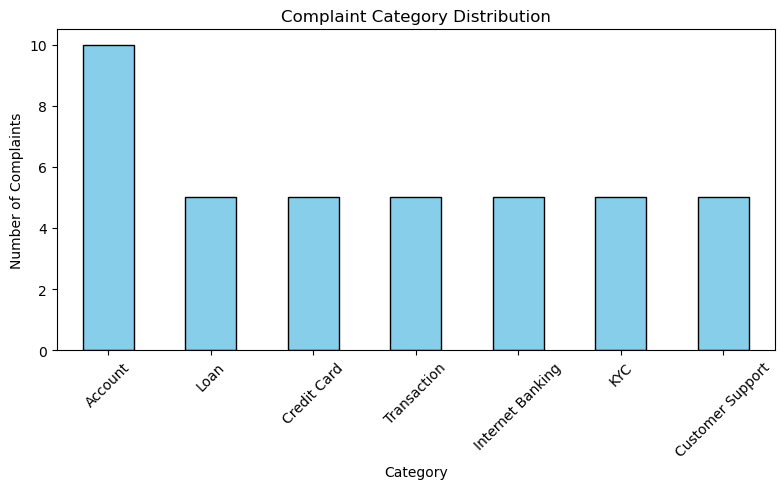

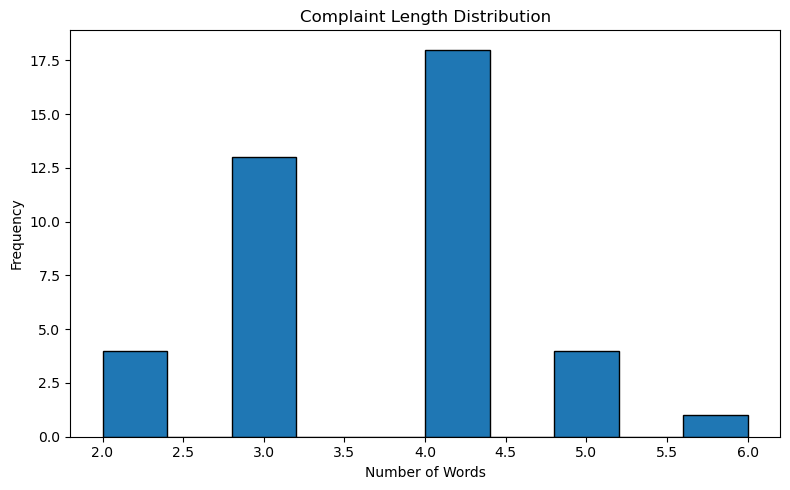


Top 20 Most Frequent Words

------------------------------------------------------------
card                 7
failed               6
unable               6
account              6
credit               5
loan                 5
money                4
banking              4
kyc                  4
transaction          3
internet             3
verification         3
customer             3
support              3
payment              2
pending              2
amount               2
deducted             2
received             2
password             2


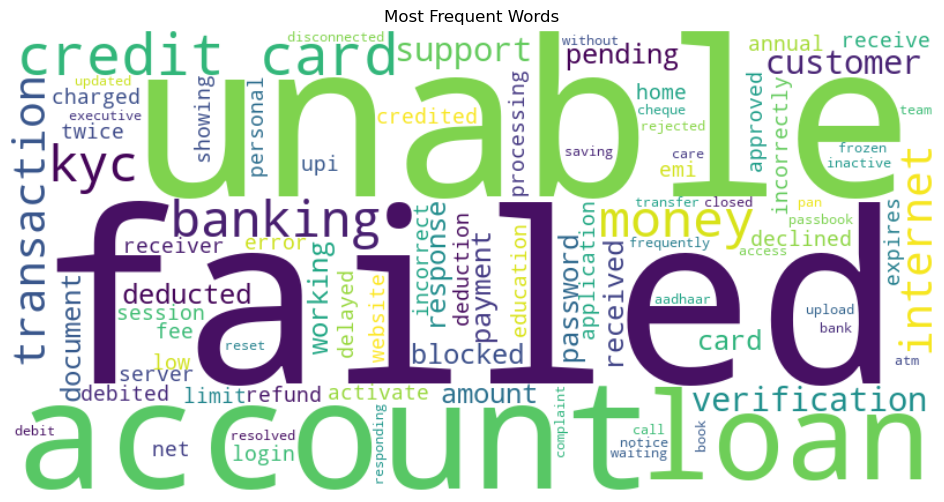


Top 20 Most Frequent Bigrams

------------------------------------------------------------
credit card                    5
internet banking               3
payment failed                 2
money deducted                 2
verification failed            2
kyc document                   2
customer support               2
card payment                   1
card transaction               1
transaction declined           1
unable activate                1
activate credit                1
card limit                     1
limit low                      1
annual credit                  1
card fee                       1
fee charged                    1
charged incorrectly            1
loan application               1
application pending            1


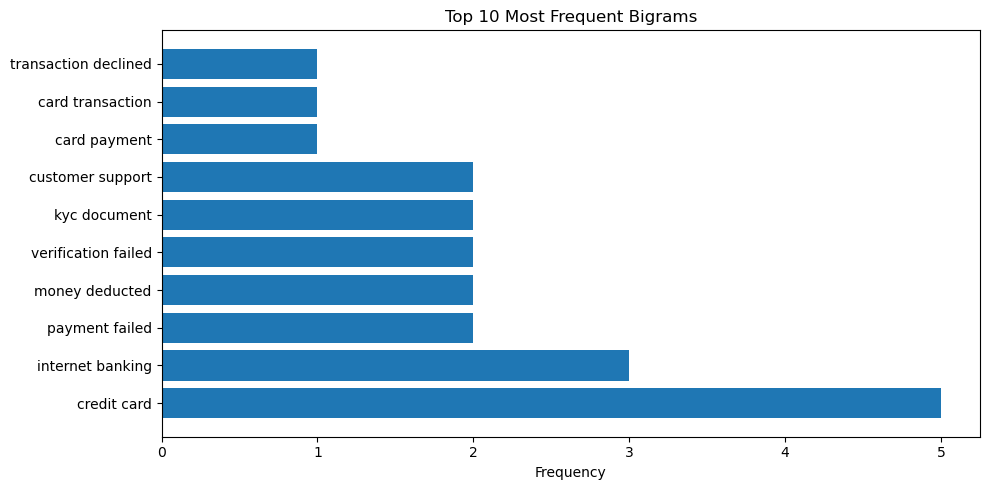


Class Percentage Distribution

Category
Account             25.0
Loan                12.5
Credit Card         12.5
Transaction         12.5
Internet Banking    12.5
KYC                 12.5
Customer Support    12.5
Name: proportion, dtype: float64


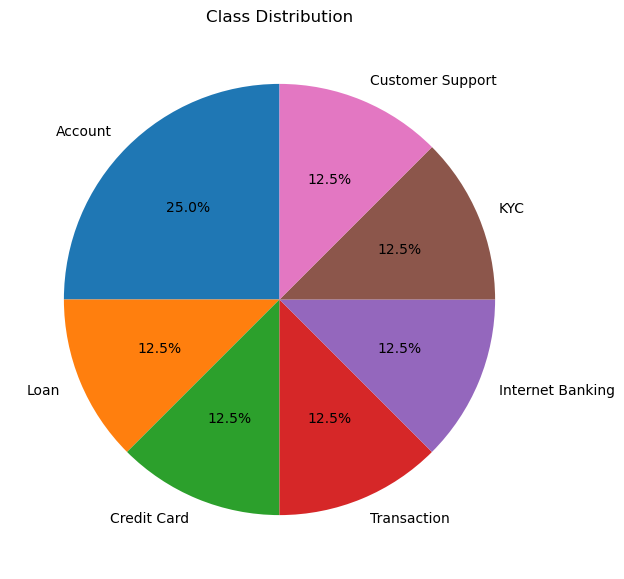


STEP 5 COMPLETED SUCCESSFULLY


In [5]:
# ==========================================================
# AI Banking Assistant
# Module 9 - Complaint Classification
# Step 5 - Exploratory Data Analysis
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer

print("="*70)
print("EXPLORATORY DATA ANALYSIS")
print("="*70)

# ==========================================================
# Load Cleaned Dataset
# ==========================================================

df = pd.read_csv(r"..\datasets\complaints_cleaned.csv")

# ==========================================================
# Complaint Category Distribution
# ==========================================================

print("\nComplaint Category Distribution\n")
print(df["Category"].value_counts())

plt.figure(figsize=(8,5))

df["Category"].value_counts().plot(
    kind="bar",
    color="skyblue",
    edgecolor="black"
)

plt.title("Complaint Category Distribution")
plt.xlabel("Category")
plt.ylabel("Number of Complaints")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# ==========================================================
# Complaint Length Distribution
# ==========================================================

df["Complaint_Length"] = df["Clean_Complaint"].apply(
    lambda x: len(str(x).split())
)

plt.figure(figsize=(8,5))

plt.hist(
    df["Complaint_Length"],
    bins=10,
    edgecolor="black"
)

plt.title("Complaint Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# ==========================================================
# Most Frequent Words
# ==========================================================

all_words = " ".join(df["Clean_Complaint"]).split()

word_counts = Counter(all_words)

top_words = word_counts.most_common(20)

print("\nTop 20 Most Frequent Words\n")
print("-"*60)

for word, count in top_words:
    print(f"{word:20} {count}")

# ==========================================================
# Word Cloud
# ==========================================================

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(" ".join(all_words))

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Frequent Words")
plt.show()

# ==========================================================
# Most Frequent Bigrams
# ==========================================================

vectorizer = CountVectorizer(ngram_range=(2,2))

X = vectorizer.fit_transform(df["Clean_Complaint"])

bigram_counts = X.sum(axis=0)

bigram_freq = [

    (word, bigram_counts[0, idx])

    for word, idx in vectorizer.vocabulary_.items()

]

bigram_freq = sorted(

    bigram_freq,

    key=lambda x: x[1],

    reverse=True

)

print("\nTop 20 Most Frequent Bigrams\n")
print("-"*60)

for bigram, count in bigram_freq[:20]:
    print(f"{bigram:30} {count}")

# ==========================================================
# Plot Top 10 Bigrams
# ==========================================================

top10 = bigram_freq[:10]

bigrams = [x[0] for x in top10]
counts = [x[1] for x in top10]

plt.figure(figsize=(10,5))

plt.barh(
    bigrams,
    counts
)

plt.xlabel("Frequency")
plt.title("Top 10 Most Frequent Bigrams")

plt.tight_layout()
plt.show()

# ==========================================================
# Class Imbalance
# ==========================================================

print("\nClass Percentage Distribution\n")

class_percent = (

    df["Category"]

    .value_counts(normalize=True)

    * 100

)

print(class_percent.round(2))

plt.figure(figsize=(7,7))

plt.pie(

    class_percent,

    labels=class_percent.index,

    autopct="%1.1f%%",

    startangle=90

)

plt.title("Class Distribution")

plt.show()

# ==========================================================
# Completed
# ==========================================================

print("\n"+"="*70)
print("STEP 5 COMPLETED SUCCESSFULLY")
print("="*70)

In [6]:
# ==========================================================
# AI Banking Assistant
# Module 9 - Complaint Classification
# Step 6 - TF-IDF Feature Extraction
# ==========================================================

import pandas as pd
import joblib
import os

from sklearn.feature_extraction.text import TfidfVectorizer

print("=" * 70)
print("STEP 6 - TF-IDF FEATURE EXTRACTION")
print("=" * 70)

# ==========================================================
# Load Cleaned Dataset
# ==========================================================

df = pd.read_csv(r"..\datasets\complaints_cleaned.csv")

# ==========================================================
# Features and Target
# ==========================================================

X = df["Clean_Complaint"]

y = df["Category"]

print("\nNumber of Samples :", len(X))

# ==========================================================
# TF-IDF Vectorizer
# ==========================================================

tfidf = TfidfVectorizer(

    lowercase=True,

    stop_words="english",

    max_features=5000,

    ngram_range=(1,2)

)

# ==========================================================
# Fit and Transform
# ==========================================================

X_tfidf = tfidf.fit_transform(X)

print("\nTF-IDF Transformation Completed")

print("\nShape of TF-IDF Matrix")

print(X_tfidf.shape)

# ==========================================================
# Display Sample Features
# ==========================================================

feature_names = tfidf.get_feature_names_out()

print("\nFirst 30 Features")

print("-"*70)

for feature in feature_names[:30]:
    print(feature)

# ==========================================================
# Display TF-IDF Matrix
# ==========================================================

tfidf_df = pd.DataFrame(

    X_tfidf.toarray(),

    columns=feature_names

)

print("\nFirst 5 Rows of TF-IDF Matrix")

print(tfidf_df.head())

# ==========================================================
# Create Models Folder
# ==========================================================

os.makedirs(r"..\models", exist_ok=True)

# ==========================================================
# Save TF-IDF Vectorizer
# ==========================================================

joblib.dump(

    tfidf,

    r"..\models\tfidf_vectorizer.pkl"

)

print("\nTF-IDF Vectorizer Saved Successfully")

print(r"Location : ..\models\tfidf_vectorizer.pkl")

# ==========================================================
# Save TF-IDF Matrix (Optional)
# ==========================================================

tfidf_df.to_csv(

    r"..\datasets\tfidf_features.csv",

    index=False

)

print("\nTF-IDF Feature Matrix Saved Successfully")

print(r"Location : ..\datasets\tfidf_features.csv")

# ==========================================================
# Completed
# ==========================================================

print("\n" + "=" * 70)
print("STEP 6 COMPLETED SUCCESSFULLY")
print("=" * 70)

STEP 6 - TF-IDF FEATURE EXTRACTION

Number of Samples : 40

TF-IDF Transformation Completed

Shape of TF-IDF Matrix
(40, 174)

First 30 Features
----------------------------------------------------------------------
aadhaar
aadhaar verification
access
access account
account
account blocked
account closed
account frozen
account inactive
account password
activate
activate credit
annual
annual credit
application
application pending
approved
atm
atm card
bank
bank account
banking
banking password
banking session
blocked
book
book received
card
card blocked
card fee

First 5 Rows of TF-IDF Matrix
   aadhaar  aadhaar verification  access  access account  account  \
0      0.0                   0.0     0.0             0.0      0.0   
1      0.0                   0.0     0.0             0.0      0.0   
2      0.0                   0.0     0.0             0.0      0.0   
3      0.0                   0.0     0.0             0.0      0.0   
4      0.0                   0.0     0.0             0.0

In [7]:
# ==========================================================
# AI Banking Assistant
# Module 9 - Complaint Classification
# Step 7 - Split Dataset
# ==========================================================

import pandas as pd
import joblib
import os

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

print("=" * 70)
print("STEP 7 - SPLIT DATASET")
print("=" * 70)

# ==========================================================
# Load Cleaned Dataset
# ==========================================================

df = pd.read_csv(r"..\datasets\complaints_cleaned.csv")

# ==========================================================
# Features and Target
# ==========================================================

X = df["Clean_Complaint"]

y = df["Category"]

print("\nTotal Samples :", len(df))

# ==========================================================
# TF-IDF Vectorizer
# ==========================================================

tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=5000,
    ngram_range=(1, 2)
)

X_tfidf = tfidf.fit_transform(X)

print("\nTF-IDF Shape :", X_tfidf.shape)

# ==========================================================
# Train Test Split
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ==========================================================
# Display Split Information
# ==========================================================

print("\n" + "=" * 70)
print("TRAIN TEST SPLIT")
print("=" * 70)

print(f"Training Samples : {X_train.shape[0]}")
print(f"Testing Samples  : {X_test.shape[0]}")

print(f"\nTraining Labels : {len(y_train)}")
print(f"Testing Labels  : {len(y_test)}")

print("\nTraining Matrix Shape :", X_train.shape)
print("Testing Matrix Shape  :", X_test.shape)

# ==========================================================
# Save TF-IDF Vectorizer
# ==========================================================

os.makedirs(r"..\models", exist_ok=True)

joblib.dump(
    tfidf,
    r"..\models\tfidf_vectorizer.pkl"
)

print("\nTF-IDF Vectorizer Saved Successfully")

# ==========================================================
# Save Split Data
# ==========================================================

os.makedirs(r"..\datasets\processed", exist_ok=True)

joblib.dump(X_train, r"..\datasets\processed\X_train.pkl")
joblib.dump(X_test, r"..\datasets\processed\X_test.pkl")
joblib.dump(y_train, r"..\datasets\processed\y_train.pkl")
joblib.dump(y_test, r"..\datasets\processed\y_test.pkl")

print("\nTraining and Testing Data Saved Successfully")

print("\nSaved Files")
print("-" * 70)
print("X_train.pkl")
print("X_test.pkl")
print("y_train.pkl")
print("y_test.pkl")

print("\n" + "=" * 70)
print("STEP 7 COMPLETED SUCCESSFULLY")
print("=" * 70)

STEP 7 - SPLIT DATASET

Total Samples : 40

TF-IDF Shape : (40, 174)

TRAIN TEST SPLIT
Training Samples : 32
Testing Samples  : 8

Training Labels : 32
Testing Labels  : 8

Training Matrix Shape : (32, 174)
Testing Matrix Shape  : (8, 174)

TF-IDF Vectorizer Saved Successfully

Training and Testing Data Saved Successfully

Saved Files
----------------------------------------------------------------------
X_train.pkl
X_test.pkl
y_train.pkl
y_test.pkl

STEP 7 COMPLETED SUCCESSFULLY


STEP 8 - TRAIN MULTIPLE MODELS

Dataset Loaded Successfully
(40, 3)

TF-IDF Shape : (40, 174)

Training Samples : 32
Testing Samples  : 8

MODEL TRAINING

Training Multinomial Naive Bayes...
Accuracy : 0.3750

Classification Report
                  precision    recall  f1-score   support

         Account       0.29      1.00      0.44         2
     Credit Card       0.00      0.00      0.00         1
Customer Support       1.00      1.00      1.00         1
Internet Banking       0.00      0.00      0.00         1
             KYC       0.00      0.00      0.00         1
            Loan       0.00      0.00      0.00         1
     Transaction       0.00      0.00      0.00         1

        accuracy                           0.38         8
       macro avg       0.18      0.29      0.21         8
    weighted avg       0.20      0.38      0.24         8


Training Logistic Regression...
Accuracy : 0.3750

Classification Report
                  precision    recall  f1-score   sup

C:\Users\aswin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\aswin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\aswin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\aswin\anaconda3\Lib\site-packag

Accuracy : 0.8750

Classification Report
                  precision    recall  f1-score   support

         Account       0.67      1.00      0.80         2
     Credit Card       1.00      1.00      1.00         1
Customer Support       1.00      1.00      1.00         1
Internet Banking       1.00      1.00      1.00         1
             KYC       1.00      1.00      1.00         1
            Loan       1.00      1.00      1.00         1
     Transaction       0.00      0.00      0.00         1

        accuracy                           0.88         8
       macro avg       0.81      0.86      0.83         8
    weighted avg       0.79      0.88      0.82         8


MODEL COMPARISON
Multinomial Naive Bayes        0.3750
Logistic Regression            0.3750
Linear SVM                     0.8750
Random Forest                  0.8750

BEST MODEL
Model    : Linear SVM
Accuracy : 87.5 %


C:\Users\aswin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\aswin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\aswin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


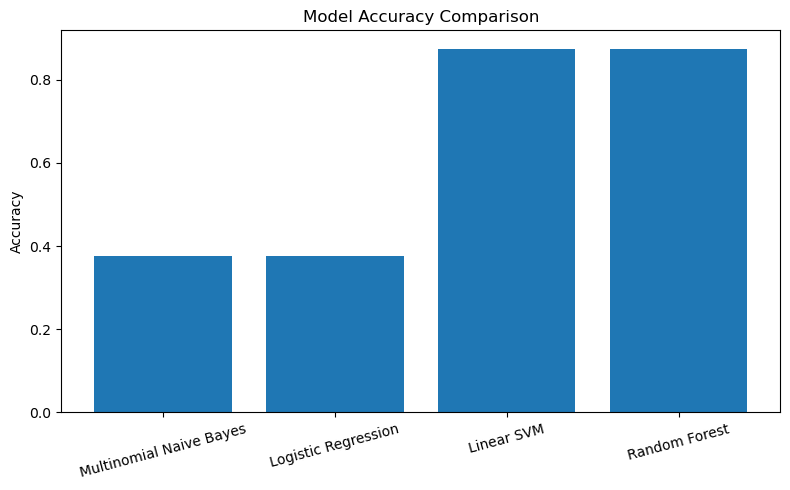


Confusion Matrix
[[2 0 0 0 0 0 0]
 [0 1 0 0 0 0 0]
 [0 0 1 0 0 0 0]
 [0 0 0 1 0 0 0]
 [0 0 0 0 1 0 0]
 [0 0 0 0 0 1 0]
 [0 1 0 0 0 0 0]]

Best Model Stored Successfully

STEP 8 COMPLETED SUCCESSFULLY


In [8]:
# ==========================================================
# AI Banking Assistant
# Module 9 - Complaint Classification
# Step 8 - Train Multiple Models
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("=" * 70)
print("STEP 8 - TRAIN MULTIPLE MODELS")
print("=" * 70)

# ==========================================================
# Load Dataset
# ==========================================================

df = pd.read_csv(r"..\datasets\complaints_cleaned.csv")

print("\nDataset Loaded Successfully")
print(df.shape)

# ==========================================================
# Features and Target
# ==========================================================

X = df["Clean_Complaint"]
y = df["Category"]

# ==========================================================
# TF-IDF Vectorization
# ==========================================================

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=5000,
    ngram_range=(1,2)
)

X = tfidf.fit_transform(X)

print("\nTF-IDF Shape :", X.shape)

# ==========================================================
# Train Test Split
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])

# ==========================================================
# Models
# ==========================================================

models = {

    "Multinomial Naive Bayes":
        MultinomialNB(),

    "Logistic Regression":
        LogisticRegression(max_iter=1000),

    "Linear SVM":
        LinearSVC(),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            random_state=42
        )

}

# ==========================================================
# Train Models
# ==========================================================

results = {}

best_model = None
best_accuracy = 0
best_model_name = ""

print("\n" + "="*70)
print("MODEL TRAINING")
print("="*70)

for name, model in models.items():

    print(f"\nTraining {name}...")

    model.fit(X_train, y_train)

    prediction = model.predict(X_test)

    accuracy = accuracy_score(
        y_test,
        prediction
    )

    results[name] = accuracy

    print(f"Accuracy : {accuracy:.4f}")

    print("\nClassification Report")

    print(
        classification_report(
            y_test,
            prediction
        )
    )

    if accuracy > best_accuracy:

        best_accuracy = accuracy

        best_model = model

        best_model_name = name

# ==========================================================
# Accuracy Comparison
# ==========================================================

print("\n" + "="*70)
print("MODEL COMPARISON")
print("="*70)

for name, score in results.items():

    print(f"{name:30} {score:.4f}")

# ==========================================================
# Best Model
# ==========================================================

print("\n"+"="*70)
print("BEST MODEL")
print("="*70)

print("Model    :", best_model_name)
print("Accuracy :", round(best_accuracy*100,2), "%")

# ==========================================================
# Accuracy Plot
# ==========================================================

plt.figure(figsize=(8,5))

plt.bar(
    results.keys(),
    results.values()
)

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.xticks(rotation=15)

plt.tight_layout()

plt.show()

# ==========================================================
# Confusion Matrix (Best Model)
# ==========================================================

best_prediction = best_model.predict(X_test)

cm = confusion_matrix(
    y_test,
    best_prediction
)

print("\nConfusion Matrix")

print(cm)

# ==========================================================
# Store Best Model
# ==========================================================

trained_model = best_model

print("\nBest Model Stored Successfully")

print("\n"+"="*70)
print("STEP 8 COMPLETED SUCCESSFULLY")
print("="*70)

STEP 9 - MODEL EVALUATION

Dataset Loaded Successfully
(40, 3)

MODEL EVALUATION

Multinomial Naive Bayes
----------------------------------------------------------------------
Accuracy : 0.3750
Precision: 0.1964
Recall   : 0.3750
F1 Score : 0.2361

Classification Report

                  precision    recall  f1-score   support

         Account       0.29      1.00      0.44         2
     Credit Card       0.00      0.00      0.00         1
Customer Support       1.00      1.00      1.00         1
Internet Banking       0.00      0.00      0.00         1
             KYC       0.00      0.00      0.00         1
            Loan       0.00      0.00      0.00         1
     Transaction       0.00      0.00      0.00         1

        accuracy                           0.38         8
       macro avg       0.18      0.29      0.21         8
    weighted avg       0.20      0.38      0.24         8



<Figure size 600x600 with 0 Axes>

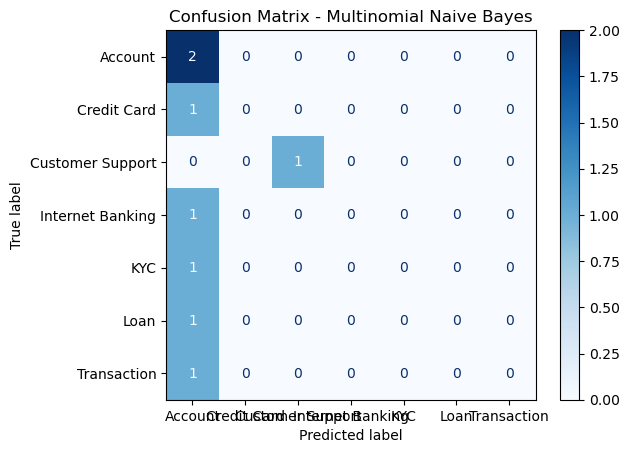


Logistic Regression
----------------------------------------------------------------------
Accuracy : 0.3750
Precision: 0.1964
Recall   : 0.3750
F1 Score : 0.2361

Classification Report

                  precision    recall  f1-score   support

         Account       0.29      1.00      0.44         2
     Credit Card       0.00      0.00      0.00         1
Customer Support       1.00      1.00      1.00         1
Internet Banking       0.00      0.00      0.00         1
             KYC       0.00      0.00      0.00         1
            Loan       0.00      0.00      0.00         1
     Transaction       0.00      0.00      0.00         1

        accuracy                           0.38         8
       macro avg       0.18      0.29      0.21         8
    weighted avg       0.20      0.38      0.24         8



<Figure size 600x600 with 0 Axes>

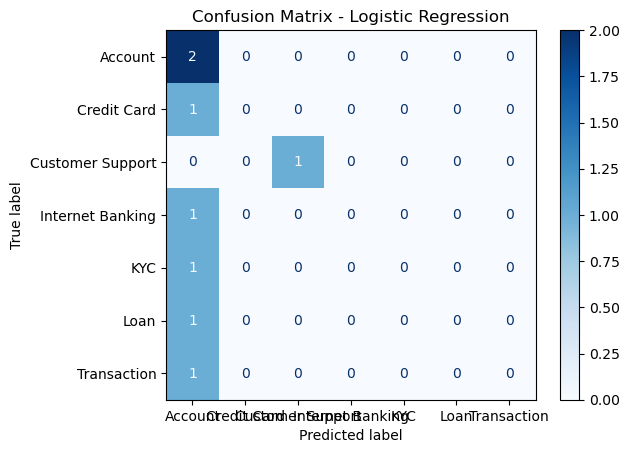


Linear SVM
----------------------------------------------------------------------
Accuracy : 0.8750
Precision: 0.8125
Recall   : 0.8750
F1 Score : 0.8333

Classification Report

                  precision    recall  f1-score   support

         Account       1.00      1.00      1.00         2
     Credit Card       0.50      1.00      0.67         1
Customer Support       1.00      1.00      1.00         1
Internet Banking       1.00      1.00      1.00         1
             KYC       1.00      1.00      1.00         1
            Loan       1.00      1.00      1.00         1
     Transaction       0.00      0.00      0.00         1

        accuracy                           0.88         8
       macro avg       0.79      0.86      0.81         8
    weighted avg       0.81      0.88      0.83         8



<Figure size 600x600 with 0 Axes>

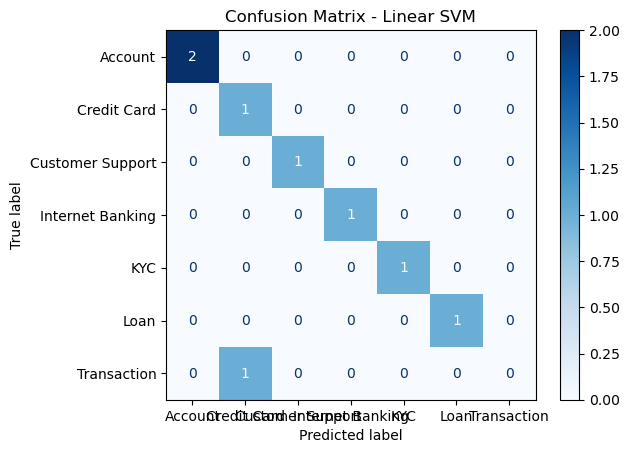


Random Forest
----------------------------------------------------------------------
Accuracy : 0.8750
Precision: 0.7917
Recall   : 0.8750
F1 Score : 0.8250

Classification Report

                  precision    recall  f1-score   support

         Account       0.67      1.00      0.80         2
     Credit Card       1.00      1.00      1.00         1
Customer Support       1.00      1.00      1.00         1
Internet Banking       1.00      1.00      1.00         1
             KYC       1.00      1.00      1.00         1
            Loan       1.00      1.00      1.00         1
     Transaction       0.00      0.00      0.00         1

        accuracy                           0.88         8
       macro avg       0.81      0.86      0.83         8
    weighted avg       0.79      0.88      0.82         8



<Figure size 600x600 with 0 Axes>

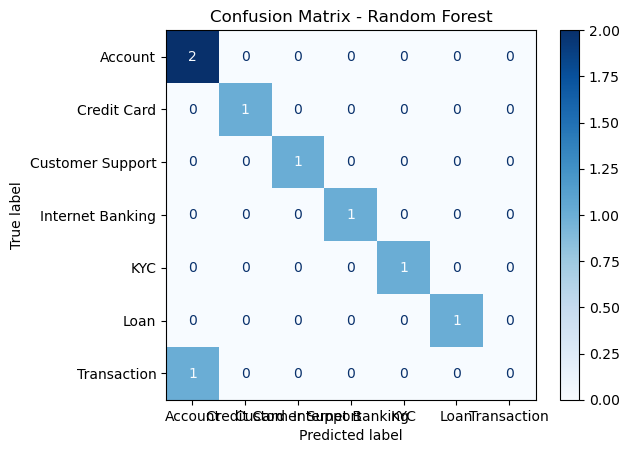


MODEL COMPARISON
                     Model  Accuracy  Precision  Recall  F1 Score
0  Multinomial Naive Bayes     0.375   0.196429   0.375  0.236111
1      Logistic Regression     0.375   0.196429   0.375  0.236111
2               Linear SVM     0.875   0.812500   0.875  0.833333
3            Random Forest     0.875   0.791667   0.875  0.825000


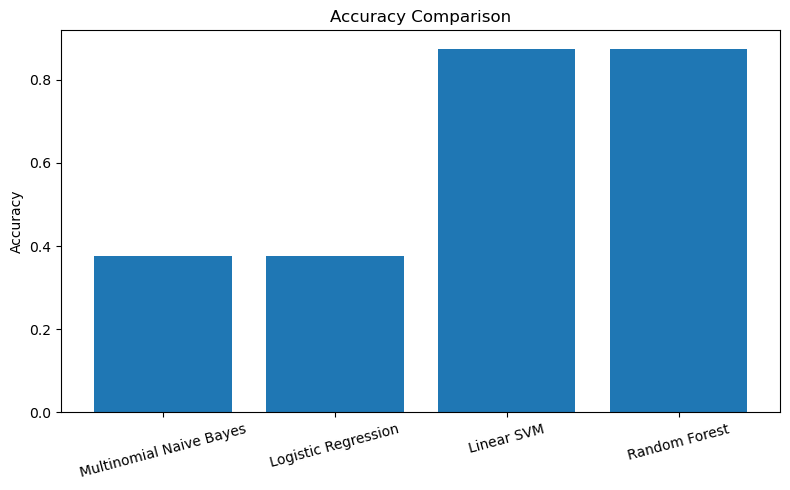


BEST MODEL
Model Name : Linear SVM
Accuracy   : 87.5 %

Best Model Stored Successfully

STEP 9 COMPLETED SUCCESSFULLY


In [9]:
# ==========================================================
# AI Banking Assistant
# Module 9 - Complaint Classification
# Step 9 - Evaluate Models
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

print("="*70)
print("STEP 9 - MODEL EVALUATION")
print("="*70)

# ==========================================================
# Load Dataset
# ==========================================================

df = pd.read_csv(r"..\datasets\complaints_cleaned.csv")

print("\nDataset Loaded Successfully")
print(df.shape)

# ==========================================================
# Features and Target
# ==========================================================

X = df["Clean_Complaint"]
y = df["Category"]

# ==========================================================
# TF-IDF
# ==========================================================

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=5000,
    ngram_range=(1,2)
)

X = tfidf.fit_transform(X)

# ==========================================================
# Split Dataset
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ==========================================================
# Models
# ==========================================================

models = {

    "Multinomial Naive Bayes": MultinomialNB(),

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Linear SVM": LinearSVC(),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    )

}

# ==========================================================
# Evaluation
# ==========================================================

results = []

best_model = None
best_model_name = ""
best_accuracy = 0

print("\n"+"="*70)
print("MODEL EVALUATION")
print("="*70)

for name, model in models.items():

    print(f"\n{name}")
    print("-"*70)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

    print("\nClassification Report\n")

    print(
        classification_report(
            y_test,
            y_pred,
            zero_division=0
        )
    )

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,6))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=model.classes_
    )

    disp.plot(cmap="Blues", values_format="d")

    plt.title(f"Confusion Matrix - {name}")

    plt.show()

    results.append([

        name,

        accuracy,

        precision,

        recall,

        f1

    ])

    if accuracy > best_accuracy:

        best_accuracy = accuracy

        best_model = model

        best_model_name = name

# ==========================================================
# Comparison Table
# ==========================================================

results_df = pd.DataFrame(

    results,

    columns=[

        "Model",

        "Accuracy",

        "Precision",

        "Recall",

        "F1 Score"

    ]

)

print("\n"+"="*70)
print("MODEL COMPARISON")
print("="*70)

print(results_df)

# ==========================================================
# Accuracy Plot
# ==========================================================

plt.figure(figsize=(8,5))

plt.bar(

    results_df["Model"],

    results_df["Accuracy"]

)

plt.title("Accuracy Comparison")

plt.ylabel("Accuracy")

plt.xticks(rotation=15)

plt.tight_layout()

plt.show()

# ==========================================================
# Best Model
# ==========================================================

print("\n"+"="*70)
print("BEST MODEL")
print("="*70)

print("Model Name :", best_model_name)

print("Accuracy   :", round(best_accuracy*100,2), "%")

# ==========================================================
# Store Best Model
# ==========================================================

trained_model = best_model

print("\nBest Model Stored Successfully")

print("\n"+"="*70)
print("STEP 9 COMPLETED SUCCESSFULLY")
print("="*70)

In [10]:
# ==========================================================
# AI Banking Assistant
# Module 9 - Complaint Classification
# Step 10 - Save Model
# ==========================================================

import os
import joblib

print("="*70)
print("SAVING MODEL")
print("="*70)

# ==========================================================
# Create Models Folder
# ==========================================================

os.makedirs(r"..\models", exist_ok=True)

# ==========================================================
# Save Best Model
# ==========================================================

joblib.dump(
    trained_model,
    r"..\models\complaint_classifier.pkl"
)

print("Complaint Classification Model Saved Successfully")

# ==========================================================
# Save TF-IDF Vectorizer
# ==========================================================

joblib.dump(
    tfidf,
    r"..\models\tfidf_vectorizer.pkl"
)

print("TF-IDF Vectorizer Saved Successfully")

# ==========================================================
# Verify Files
# ==========================================================

print("\nSaved Files")
print("-"*70)

print(r"..\models\complaint_classifier.pkl")
print(r"..\models\tfidf_vectorizer.pkl")

print("\n"+"="*70)
print("STEP 10 COMPLETED SUCCESSFULLY")
print("="*70)

SAVING MODEL
Complaint Classification Model Saved Successfully
TF-IDF Vectorizer Saved Successfully

Saved Files
----------------------------------------------------------------------
..\models\complaint_classifier.pkl
..\models\tfidf_vectorizer.pkl

STEP 10 COMPLETED SUCCESSFULLY
